## 1. Imports

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image


## 2. Load and preprocess images (image level)

In [2]:
BASE_DIR = r"./BSDS500-master/BSDS500/data/images"   # change this to your extracted folder path
SPLIT = "train"          # "train", "test", or "val"
IMG_SIZE = (32, 32)      # resize target so every image gives a same-length vector

def load_images(base_dir, split, img_size):
    folder = os.path.join(base_dir, split)
    files = sorted(f for f in os.listdir(folder) if f.lower().endswith((".jpg", ".jpeg", ".png")))
    vectors, names = [], []
    for f in files:
        img = Image.open(os.path.join(folder, f)).convert("L").resize(img_size)
        vectors.append(np.asarray(img, dtype=np.float32).flatten())
        names.append(f)
    return np.array(vectors), names

X, names = load_images(BASE_DIR, SPLIT, IMG_SIZE)
print("Loaded", X.shape[0], "images, each flattened to", X.shape[1], "-dim vector")


Loaded 200 images, each flattened to 1024 -dim vector


## 3. Image-level features
Instead of working pixel-by-pixel, each image is summarised by two scalar descriptors:
mean intensity and intensity spread (std). Outlier detection is applied on these
per-image features.

In [3]:
mean_int = X.mean(axis=1)   # average brightness of each image
std_int = X.std(axis=1)     # contrast / spread of each image

print(f"mean intensity range : {mean_int.min():.2f} - {mean_int.max():.2f}")
print(f"std intensity range  : {std_int.min():.2f} - {std_int.max():.2f}")


mean intensity range : 33.49 - 188.81
std intensity range  : 8.86 - 81.33


## 4. Outlier detection - Z-score method

In [4]:
def zscore_outliers(arr, thresh=3.0):
    z = (arr - arr.mean()) / arr.std()
    return np.abs(z) > thresh, z

z_mean_mask, z_mean = zscore_outliers(mean_int)
z_std_mask, z_std = zscore_outliers(std_int)
z_outlier_mask = z_mean_mask | z_std_mask

print("Z-score outliers -> mean:", z_mean_mask.sum(), " std:", z_std_mask.sum(),
      " combined:", z_outlier_mask.sum())


Z-score outliers -> mean: 0  std: 0  combined: 0


## 5. Outlier detection - IQR method

In [5]:
def iqr_outliers(arr, k=1.5):
    q1, q3 = np.percentile(arr, [25, 75])
    iqr = q3 - q1
    lower, upper = q1 - k * iqr, q3 + k * iqr
    return (arr < lower) | (arr > upper), (lower, upper)

iqr_mean_mask, mean_bounds = iqr_outliers(mean_int)
iqr_std_mask, std_bounds = iqr_outliers(std_int)
iqr_outlier_mask = iqr_mean_mask | iqr_std_mask

print("IQR outliers -> mean:", iqr_mean_mask.sum(), " std:", iqr_std_mask.sum(),
      " combined:", iqr_outlier_mask.sum())
print(f"mean_int bounds: [{mean_bounds[0]:.2f}, {mean_bounds[1]:.2f}]")
print(f"std_int  bounds: [{std_bounds[0]:.2f}, {std_bounds[1]:.2f}]")


IQR outliers -> mean: 2  std: 1  combined: 3
mean_int bounds: [35.93, 184.24]
std_int  bounds: [5.48, 81.04]


## 6. Treatment of outliers
Flagged values are capped (winsorized) to the nearest IQR bound instead of being
discarded, so the dataset size is preserved.

In [6]:
mean_int_treated = np.clip(mean_int, *mean_bounds)
std_int_treated = np.clip(std_int, *std_bounds)

n_flagged = iqr_outlier_mask.sum()
print(f"Images flagged as outliers (IQR, union of both features): "
      f"{n_flagged} of {len(names)} ({100*n_flagged/len(names):.1f}%)")
print("Outlier files:", [names[i] for i in np.where(iqr_outlier_mask)[0]])


Images flagged as outliers (IQR, union of both features): 3 of 200 (1.5%)
Outlier files: ['245051.jpg', '323016.jpg', '42078.jpg']


## 7. Output + Analysis

/tmp/ipykernel_565/149250155.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([mean_int, std_int], labels=["mean_int", "std_int"])
/tmp/ipykernel_565/149250155.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([mean_int_treated, std_int_treated], labels=["mean_int", "std_int"])


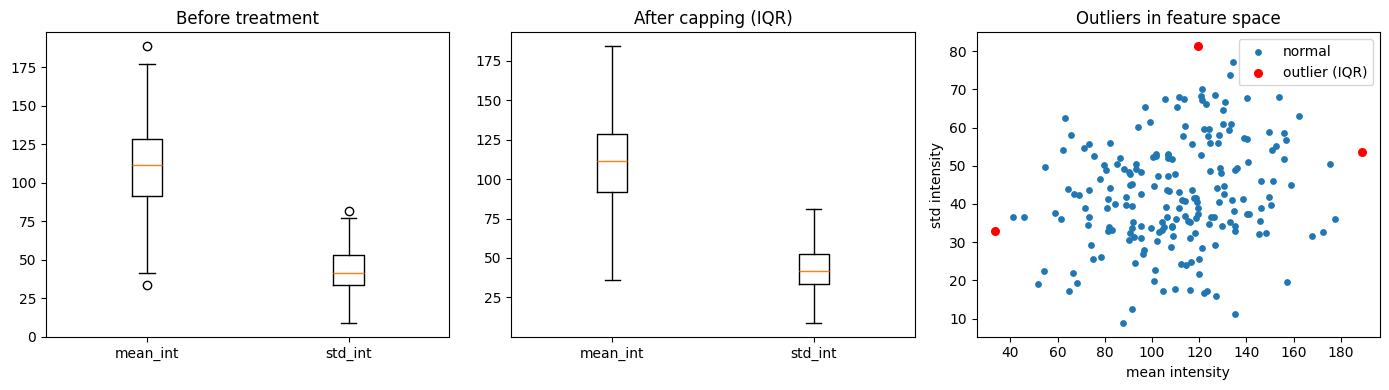

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].boxplot([mean_int, std_int], labels=["mean_int", "std_int"])
axes[0].set_title("Before treatment")

axes[1].boxplot([mean_int_treated, std_int_treated], labels=["mean_int", "std_int"])
axes[1].set_title("After capping (IQR)")

axes[2].scatter(mean_int, std_int, c="tab:blue", s=15, label="normal")
axes[2].scatter(mean_int[iqr_outlier_mask], std_int[iqr_outlier_mask],
                c="red", s=30, label="outlier (IQR)")
axes[2].set_xlabel("mean intensity")
axes[2].set_ylabel("std intensity")
axes[2].set_title("Outliers in feature space")
axes[2].legend()

plt.tight_layout()
plt.savefig("outlier_plots.png", dpi=130)
plt.show()
